# 02. Historic Value, Decision-Time RFM, and Cohorts

**Project:** Customer Churn Prediction & Lifetime Value.

**This notebook covers:**
1. Defining the **one customer population** every later notebook shares -- who's even
   eligible to be scored, and why
2. A stratified train/validation/test split, fixed here and reused unchanged through
   notebook 6
3. Historic CLV (observed revenue, not a forecast)
4. RFM segmentation, with quintile boundaries fit on training customers only
5. Cohort retention as a descriptive lens

The first iteration built each of these on a different, not-quite-matching slice of the
customer base -- notebook 2's RFM used the full customer history, notebook 4's churn
label used a 3-month holdout, and nobody had written down which customers were even
eligible for a churn label in the first place. That mismatch is exactly what produced
the project's worst bug (see notebook 5/6 for what happened when it surfaced). This
notebook exists specifically to close that gap: define the population once, split it
once, and hand every later notebook the same manifest.

### Import necessary libraries

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

CALIBRATION_END = pd.Timestamp("2011-09-01")
OBSERVATION_END = pd.Timestamp("2011-12-01")
DATA_START = pd.Timestamp("2010-12-01")

### Load & Inspect data

In [2]:
# Resolve repository paths whether Jupyter is launched from the
# repository root or from the notebooks directory.
REPO_ROOT = Path.cwd()

if not (REPO_ROOT / 'data').exists():
    REPO_ROOT = REPO_ROOT.parent

RAW_DATA = REPO_ROOT / 'data' / 'raw'
PROCESSED_DATA = REPO_ROOT / 'data' / 'processed'

In [3]:
clean = pd.read_parquet(PROCESSED_DATA / "online_retail_clean.parquet")
print(f"Rows: {len(clean):,}  Customers: {clean['CustomerID'].nunique():,}")
clean.head()

Rows: 371,767  Customers: 4,285


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 1. Who's even eligible to be scored?

"Will this customer churn" only makes sense for someone with an established buying
pattern -- you can't say someone *stopped* doing something they'd only done once. So
before any RFM or churn work happens, every customer needs to be sorted into one of
three groups, using **only calibration-period purchases** (before September 1):

- **Eligible repeat customers** -- at least two distinct calibration invoices. This is
  the population every later notebook scores, segments, and predicts on.
- **One-calibration-order customers** -- exactly one calibration invoice. There's no
  repeat pattern to measure recency or frequency against, so these customers are held
  out of the decision population entirely (not folded into a "churn risk" bucket, not
  dropped from the data -- just outside the scope of what a churn label can mean here).
- **First-seen-in-holdout customers** -- no calibration invoice at all; their first
  purchase happens after September 1. They can't be scored on September 1 information
  because there isn't any yet.

The function below builds this manifest directly from the cleaned transactions, plus
the pre-cutoff RFM inputs (recency, frequency, monetary) for whoever turns out to be
eligible.

In [4]:
def prepare_transactions(clean: pd.DataFrame) -> pd.DataFrame:
    """Re-check notebook 1's invariants before this notebook relies on them."""
    tx = clean.copy()
    tx["InvoiceDate"] = pd.to_datetime(tx["InvoiceDate"])
    assert tx["CustomerID"].notna().all()
    assert tx["InvoiceDate"].ge(DATA_START).all()
    assert tx["InvoiceDate"].lt(OBSERVATION_END).all()
    assert not tx["InvoiceNo"].astype(str).str.upper().str.startswith("C").any()
    tx["TotalPrice"] = tx["Quantity"] * tx["UnitPrice"]
    return tx

tx = prepare_transactions(clean)
print(f"Validated {len(tx):,} transaction lines")

Validated 371,767 transaction lines


In [5]:
# Collapse to one row per (customer, invoice) -- orders, not line items
cal = tx.loc[tx["InvoiceDate"] < CALIBRATION_END]
orders_cal = (cal.groupby(["CustomerID", "InvoiceNo"], as_index=False)
              .agg(InvoiceDate=("InvoiceDate", "min"), revenue=("TotalPrice", "sum")))

eligible = (orders_cal.groupby("CustomerID").agg(
    n_orders_cal=("InvoiceNo", "nunique"),
    first_purchase_cal=("InvoiceDate", "min"),
    last_purchase_cal=("InvoiceDate", "max"),
    revenue_cal=("revenue", "sum")).reset_index())

all_customers = pd.DataFrame({"CustomerID": tx["CustomerID"].drop_duplicates().sort_values().to_numpy()})
manifest = all_customers.merge(eligible, on="CustomerID", how="left", validate="one_to_one")
manifest["n_orders_cal"] = manifest["n_orders_cal"].fillna(0).astype(int)

manifest["reason"] = np.select(
    [manifest["n_orders_cal"].eq(0), manifest["n_orders_cal"].eq(1)],
    ["first_seen_in_holdout", "one_calibration_order"],
    default="eligible_repeat")
manifest["eligible_repeat"] = manifest["reason"].eq("eligible_repeat")

print(manifest["reason"].value_counts().to_string())

reason
eligible_repeat          1926
one_calibration_order    1385
first_seen_in_holdout     974


In [6]:
# The churn label itself: did an eligible customer place any order in the holdout window?
holdout = tx.loc[(tx["InvoiceDate"] >= CALIBRATION_END) & (tx["InvoiceDate"] < OBSERVATION_END)]
holdout_orders = holdout.groupby("CustomerID")["InvoiceNo"].nunique()
manifest["n_orders_holdout"] = manifest["CustomerID"].map(holdout_orders).fillna(0).astype(int)
manifest["churned"] = np.where(manifest["eligible_repeat"],
                               manifest["n_orders_holdout"].eq(0).astype(int), np.nan)

print(f"Eligible repeat customers: {manifest['eligible_repeat'].sum():,}")
print(f"Churn rate among eligible: {manifest.loc[manifest['eligible_repeat'], 'churned'].mean():.3f}")

Eligible repeat customers: 1,926
Churn rate among eligible: 0.300


**974 customers are first seen in the holdout window and 1,385 have exactly one
calibration order** -- together, more customers than are actually eligible for a churn
label. That's worth sitting with: most of this customer base either hasn't bought
enough yet, or bought for the first time too late, for "churn" to be a meaningful
question about them at all. Only the remaining **1,926 eligible repeat customers**
drive every model and segment from here on.

### A stratified split, fixed now and reused everywhere

Every later notebook needs train customers to fit on, validation customers to select a
model/threshold against, and test customers held back for a single, one-time check.
Splitting once here -- rather than re-splitting inside each notebook -- is what
guarantees notebook 5's "validation" and notebook 6's "test" actually mean the same
population throughout. 60/20/20, stratified by the churn outcome so all three
partitions have a comparable churn rate, seeded for reproducibility.

In [7]:
def assign_splits(manifest: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    out = manifest.copy()
    out["split"] = pd.NA
    pop = out.loc[out["eligible_repeat"]]
    dev_idx, test_idx = train_test_split(pop.index, test_size=0.2, random_state=seed,
                                         stratify=pop["churned"])
    train_idx, val_idx = train_test_split(dev_idx, test_size=0.25, random_state=seed,
                                          stratify=pop.loc[dev_idx, "churned"])
    out.loc[train_idx, "split"] = "train"
    out.loc[val_idx, "split"] = "validation"
    out.loc[test_idx, "split"] = "test"
    return out

manifest = assign_splits(manifest)
manifest.loc[manifest["eligible_repeat"]].groupby("split")["churned"].agg(["size", "mean"])

,size,mean
split,,
test,386,0.300518
train,1155,0.300433
validation,385,0.298701


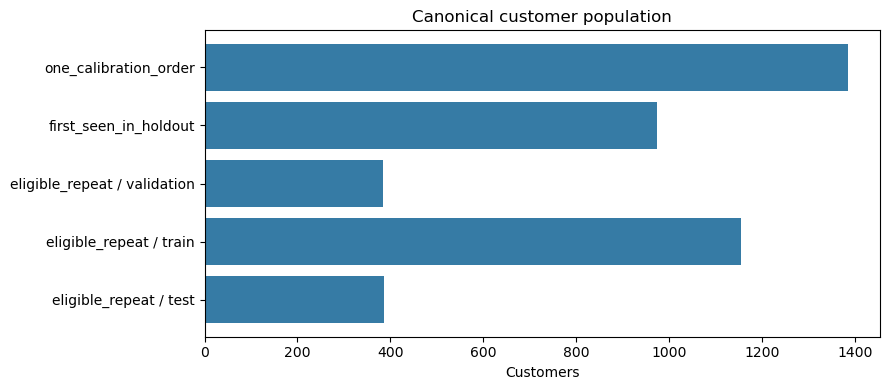

In [8]:
flow = manifest.groupby(["reason", "split"], dropna=False).size().rename("n_customers").reset_index()
flow["group"] = flow["reason"] + flow["split"].fillna("").map(lambda s: f" / {s}" if s else "")

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(flow["group"], flow["n_customers"], color="#367ba5")
ax.set(title="Canonical customer population", xlabel="Customers")
fig.tight_layout(); plt.show(); plt.close(fig)

**Observed run.** Of 4,285 cleaned customers, 1,926 are eligible repeats (1,155
train, 385 validation, 386 test); 1,385 had exactly one calibration invoice, and 974
first appear in the holdout window. The split is stratified purely for evaluation
balance -- a customer's holdout outcome is never used to decide which segment they land
in below.

## 2. Historic CLV: what's directly observed?

For an existing customer, calibration-period revenue *is* a defensible historic value
number -- no forecasting involved. Katherine Munro's "Methods for Modelling CLV"
(Towards Data Science) describes exactly this as the Stupid Simple Formula: average
order value x purchase frequency x customer lifespan. Multiplying it out that way is
algebraically the same total as summing revenue directly -- the payoff isn't a
different number, it's that each factor becomes independently inspectable. Two
customers with the same total revenue can get there very differently -- one buying
rarely in large orders, one buying often in small ones -- and those look identical in a
single revenue figure but may warrant different treatment. The decomposition below
computes all three factors and checks they reconstruct the same total shown here,
rather than just asserting the equivalence.

Munro's companion piece, "From Analytics to Actual Application: CLV", also proposes
comparing historic CLV against acquisition cost as a breakeven check. Not usable here --
this dataset has no acquisition-cost or marketing-spend field to check it against, so
that piece of the article is noted rather than invented.

An assumed 25% margin is shown alongside as an explicitly-flagged scenario, not a
measured profit figure. Munro's article discusses margin-adjusted variants built from
either COGS or a transaction-level margin field; this dataset has neither, so a flat,
clearly-labeled assumption stands in rather than a "true" margin-adjusted number built
on an invented input.

In [9]:
observed = (cal.groupby("CustomerID").agg(
    revenue_cal=("TotalPrice", "sum"),
    orders_cal=("InvoiceNo", "nunique"),
    first_seen=("InvoiceDate", "min"),
    last_seen=("InvoiceDate", "max")).reset_index())

# The Stupid Simple Formula's three factors, computed explicitly rather than left
# implicit in the direct revenue sum above
observed["avg_order_value_cal"] = observed["revenue_cal"] / observed["orders_cal"]
observed["lifespan_days_cal"] = (observed["last_seen"] - observed["first_seen"]).dt.days.clip(lower=1)
observed["monthly_frequency_cal"] = observed["orders_cal"] / (observed["lifespan_days_cal"] / 30.44)
observed["stupid_simple_clv"] = (observed["avg_order_value_cal"] * observed["monthly_frequency_cal"]
                                 * (observed["lifespan_days_cal"] / 30.44))
assert np.allclose(observed["stupid_simple_clv"], observed["revenue_cal"]), \
    "the three factors should reconstruct the same total revenue, by construction"

observed["assumed_gross_profit_cal"] = 0.25 * observed["revenue_cal"]

print(observed[["revenue_cal", "orders_cal"]].describe(percentiles=[.5, .9, .99]).round(2).to_string())
print(f"\nCustomers with a calibration purchase: {len(observed):,}")
print(f"Illustrative calibration gross profit (25% margin): "
      f"£{observed['assumed_gross_profit_cal'].sum():,.2f}")

       revenue_cal  orders_cal
count      3311.00     3311.00
mean       1508.05        3.40
std        5680.79        5.49
min           2.90        1.00
50%         539.17        2.00
90%        2702.73        7.00
99%       14138.01       22.90
max      175422.94      124.00

Customers with a calibration purchase: 3,311
Illustrative calibration gross profit (25% margin): £1,248,291.55


In [10]:
# Two repeat customers with near-identical total revenue but an opposite AOV/frequency
# split -- exactly the distinction a single revenue_cal number can't show on its own.
# Restricted to orders_cal >= 2: a single-order customer's "lifespan" is a same-day
# clip artifact, not a real frequency signal.
similar_revenue = observed.loc[observed["revenue_cal"].between(500, 600) & observed["orders_cal"].ge(2)]
(similar_revenue.sort_values("avg_order_value_cal", ascending=False)
 [["CustomerID", "revenue_cal", "avg_order_value_cal", "orders_cal", "monthly_frequency_cal"]]
 .iloc[[0, -1]])

,CustomerID,revenue_cal,avg_order_value_cal,orders_cal,monthly_frequency_cal
316,12872,599.97,299.985000,2,1.602105
989,14083,533.39,76.198571,7,0.869714


Same revenue band, opposite shape: one customer gets there with a handful of large orders, the other with many small ones. A retention message built for the first (protect a high-ticket account) would land oddly for the second (encourage more frequent small purchases) -- exactly the kind of distinction the Stupid Simple Formula's decomposition is meant to surface, and exactly what gets lost if only the summed total is reported.

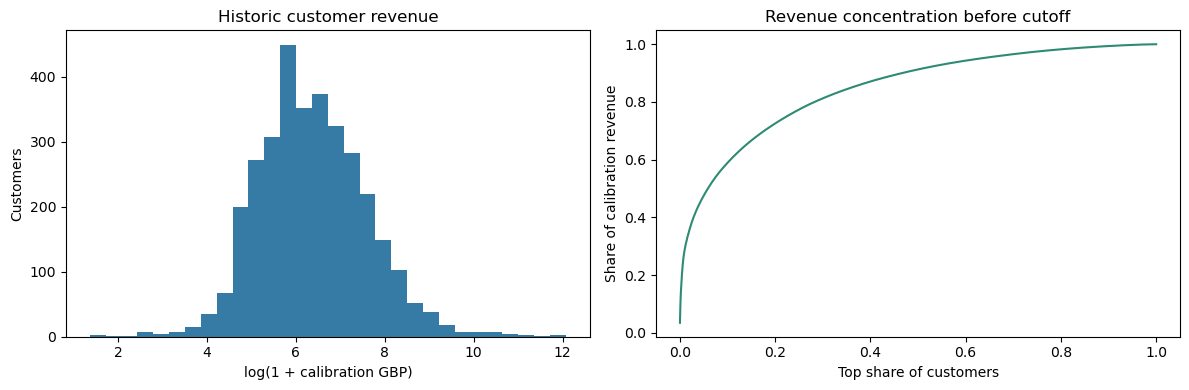

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.log1p(observed["revenue_cal"]), bins=30, color="#367ba5")
axes[0].set(title="Historic customer revenue", xlabel="log(1 + calibration GBP)", ylabel="Customers")

top = observed["revenue_cal"].sort_values(ascending=False)
axes[1].plot(np.arange(1, len(top) + 1) / len(top), top.cumsum() / top.sum(), color="#2e8b73")
axes[1].set(title="Revenue concentration before cutoff",
            xlabel="Top share of customers", ylabel="Share of calibration revenue")
fig.tight_layout(); plt.show(); plt.close(fig)

**Reading historic value.** Among the 3,311 customers with a calibration purchase,
mean observed revenue is **£1,508.05** versus a median of just **£539.17** -- the mean
is pulled hard by a right tail that reaches **£175,422.94** for a single customer. This
is the same story notebook 1 told with the top-10%-of-customers chart: a single
"average customer" number would flatten a genuinely heterogeneous population, which is
the whole motivation for the segmentation work below rather than reporting one number
and calling it CLV.

## 3. Decision-time RFM

Katherine Munro's "Methods for Modelling CLV" (Towards Data Science) is the direct
source for what follows: recency, frequency, and monetary value, tiered into quintiles
and mapped to named, actionable segments rather than left as three raw numbers. Munro's
own framing is worth keeping in mind while reading the segment rules below: RFM trades
some precision for something a marketing stakeholder can read and act on immediately,
and that tradeoff is a deliberate design choice, not a shortcut.

Computed **only from calibration-period purchases** for the 1,926 eligible repeat
customers:

- **Recency** -- days between a customer's last calibration invoice and September 1.
- **Frequency** -- count of distinct calibration invoices.
- **Monetary** -- total calibration-period revenue.

Two design choices here are worth flagging before looking at the numbers, because both
are direct responses to what went wrong the first time around.

**Quintile boundaries are fit on train customers only, then applied unchanged to
validation and test.** If the cutpoints were instead computed on the full eligible
population, a customer's segment would partly depend on who else happened to land in
the same evaluation split -- and validation/test customers would be scored against
boundaries partly informed by their own future-unseen behavior. Fitting on train and
freezing the result avoids that.

**Recency is measured from the last *calibration* purchase, not the last purchase in
the whole dataset.** A full-history recency measure would, for any customer who bought
during the holdout window, directly reveal that they didn't churn -- their "days since
last purchase" would already reflect a purchase the churn label hasn't been asked about
yet. That's exactly the leak the first iteration didn't catch until notebook 6: RFM's
snapshot date and the churn label's holdout boundary need to be the same date for RFM
to stay a legitimate *predictor* rather than a restatement of the outcome.

In [12]:
rfm_raw = manifest.loc[manifest["eligible_repeat"],
                       ["CustomerID", "n_orders_cal", "last_purchase_cal", "revenue_cal"]].copy()
rfm_raw["recency_days"] = (CALIBRATION_END - rfm_raw["last_purchase_cal"]).dt.days
rfm_raw = rfm_raw.rename(columns={"n_orders_cal": "frequency", "revenue_cal": "monetary"})
assert (rfm_raw["last_purchase_cal"] < CALIBRATION_END).all()
assert (rfm_raw["recency_days"] >= 0).all()
rfm_raw.describe().round(1)

,CustomerID,frequency,last_purchase_cal,monetary,recency_days
count,1926.0,1926.0,1926,1926.0,1926.0
mean,15317.8,5.1,2011-07-03 01:17:56.448598272,2343.9,59.5
min,12347.0,2.0,2010-12-01 15:28:00,21.3,0.0
25%,13839.0,2.0,2011-06-06 13:34:00,559.7,16.0
50%,15290.5,3.0,2011-07-19 17:03:00,1020.3,43.0
75%,16836.5,5.0,2011-08-15 12:04:15,2005.8,86.0
max,18283.0,124.0,2011-08-31 17:16:00,175422.9,273.0
std,1728.4,6.7,NaN,7325.1,55.0


### Checking independence of R, F, and M before trusting the segment sizes

If recency, frequency, and monetary value turn out to be strongly correlated with each
other, "top quintile on all three" (Champions) won't be the rare combination it sounds
like -- and some of that overlap would be mechanical rather than a real loyalty signal:
a customer who orders more often simply has more chances for one of those orders to
land recently, which pulls their recency score up independent of any change in
behavior. Worth checking before reading too much into segment sizes below.

In [13]:
train_ids = manifest.loc[manifest["split"].eq("train"), "CustomerID"]
train_rfm = rfm_raw.loc[rfm_raw["CustomerID"].isin(train_ids)]
corr = train_rfm[["recency_days", "frequency", "monetary"]].corr()
print(corr.round(2).to_string())

              recency_days  frequency  monetary
recency_days          1.00      -0.26     -0.15
frequency            -0.26       1.00      0.58
monetary             -0.15       0.58      1.00


In [14]:
print(f"Frequency <-> Monetary:  {corr.loc['frequency','monetary']:.2f}")
print(f"Recency   <-> Frequency:  {corr.loc['recency_days','frequency']:.2f}")
print(f"Recency   <-> Monetary:   {corr.loc['recency_days','monetary']:.2f}")

Frequency <-> Monetary:  0.58
Recency   <-> Frequency:  -0.26
Recency   <-> Monetary:   -0.15


Frequency and monetary value move together noticeably more than either does with
recency -- unsurprising, since more orders mechanically means more chances to
accumulate spend. Recency is close to independent of both. So a "top-tier on
frequency and monetary" combination (which several segments below require) will be more
common than three genuinely independent 20% cuts would predict -- expected, and not a
sign anything is wrong with the segmentation.

In [15]:
def fit_rfm_cutpoints(rfm: pd.DataFrame, training_ids: pd.Series) -> dict:
    train = rfm.loc[rfm["CustomerID"].isin(training_ids)]
    return {col: train[col].quantile([.2, .4, .6, .8]).to_numpy()
            for col in ("recency_days", "frequency", "monetary")}

cutpoints = fit_rfm_cutpoints(rfm_raw, train_ids)
pd.DataFrame(cutpoints, index=["p20", "p40", "p60", "p80"]).round(1)

,recency_days,frequency,monetary
p20,13.0,2.0,478.9
p40,33.0,3.0,804.4
p60,58.4,4.0,1365.0
p80,99.2,7.0,2375.4


Training recency cutpoints land at 13, 33, 58, and 99 days; frequency cutpoints at
2, 3, 4, and 7 invoices. These four numbers per column are frozen from here on -- the
same boundaries apply to validation and test customers, whatever their own distribution
looks like.

### Segment definitions

Nine segments, built from a short rule chain evaluated top to bottom. R/F/M scores run
1 (bottom quintile) to 5 (top quintile), reusing the same interpretable-over-precise
philosophy the source articles recommend: something a marketing stakeholder can read and
act on immediately, at the cost of a few edge cases landing in a broader catch-all.

1. **Champions** -- top quintile on all three (`R=5, F=5, M=5`).
2. **Loyal Customers** -- recent and frequent (`R>=4, F>=3`), regardless of spend.
3. **Recent, Low Engagement** -- recent but infrequent (`R>=4, F<=2`). New or
   occasional buyers who haven't built a pattern yet.
4. **Potential Loyalists** -- middling recency with real frequency and spend
   (`R=3, F>=3, M>=3`).
5. **Churn Risk (high value)** -- not recent, but historically frequent and
   high-spending (`R<=2, F>=4, M>=4`). These are customers who used to buy a lot and
   have gone quiet.
6. **At Risk** -- not recent, still moderately frequent (`R<=2, F>=3`), below the
   Churn Risk value bar.
7. **High-Value Infrequent Buyers** -- not recent, rarely bought, but spent well when
   they did (`R<=2, F<=2, M>=3`). Deliberately *not* labeled a churn risk: churn
   presupposes an established repeat relationship, and a customer with one or two big
   orders never had one to lose.
8. **Lost / Lowest Priority** -- not recent, infrequent, low spend on top of it
   (`R<=2, F<=2, M<=2`).
9. **Needs Attention** -- the fallback for anyone the eight rules above don't catch.

Worth noting where the fallback actually catches people: rules 5-8 all require `R<=2`,
and rule 4 requires `F>=3` and `M>=3`. A middling-recency customer (`R=3`) who doesn't
clear rule 4's frequency-and-spend bar has no other rule that applies to them, so they
land in Needs Attention by construction, not because they're a genuinely
undifferentiated group.

In [16]:
def score_rfm(rfm: pd.DataFrame, cutpoints: dict) -> pd.DataFrame:
    out = rfm.copy()
    out["R"] = 5 - np.searchsorted(cutpoints["recency_days"], out["recency_days"], side="left")
    for col, score in [("frequency", "F"), ("monetary", "M")]:
        out[score] = 1 + np.searchsorted(cutpoints[col], out[col], side="left")

    def label(row):
        r, f, m = row.R, row.F, row.M
        if r == 5 and f == 5 and m == 5: return "Champions"
        if r >= 4 and f >= 3: return "Loyal Customers"
        if r >= 4 and f <= 2: return "Recent, Low Engagement"
        if r == 3 and f >= 3 and m >= 3: return "Potential Loyalists"
        if r <= 2 and f >= 4 and m >= 4: return "Churn Risk (high value)"
        if r <= 2 and f >= 3: return "At Risk"
        if r <= 2 and f <= 2 and m >= 3: return "High-Value Infrequent Buyers"
        if r <= 2 and f <= 2 and m <= 2: return "Lost / Lowest Priority"
        return "Needs Attention"

    out["segment"] = out.apply(label, axis=1)
    assert out["CustomerID"].is_unique and out["segment"].notna().all()
    return out

rfm = score_rfm(rfm_raw, cutpoints)
assert set(rfm["CustomerID"]) == set(manifest.loc[manifest["eligible_repeat"], "CustomerID"])

segment_summary = rfm.groupby("segment").agg(
    n=("CustomerID", "size"),
    median_recency=("recency_days", "median"),
    median_frequency=("frequency", "median"),
    median_revenue=("monetary", "median")).sort_values("n", ascending=False)
segment_summary

,n,median_recency,median_frequency,median_revenue
segment,,,,
Loyal Customers,407,16.0,6.0,1850.020
Lost / Lowest Priority,385,106.0,2.0,434.590
"Recent, Low Engagement",279,15.0,3.0,707.000
Needs Attention,220,45.0,2.0,637.175
High-Value Infrequent Buyers,186,103.5,2.0,1139.360
Potential Loyalists,148,43.0,5.0,1937.695
Champions,129,7.0,14.0,5125.450
At Risk,116,91.5,4.0,997.385
Churn Risk (high value),56,83.5,6.0,2207.240


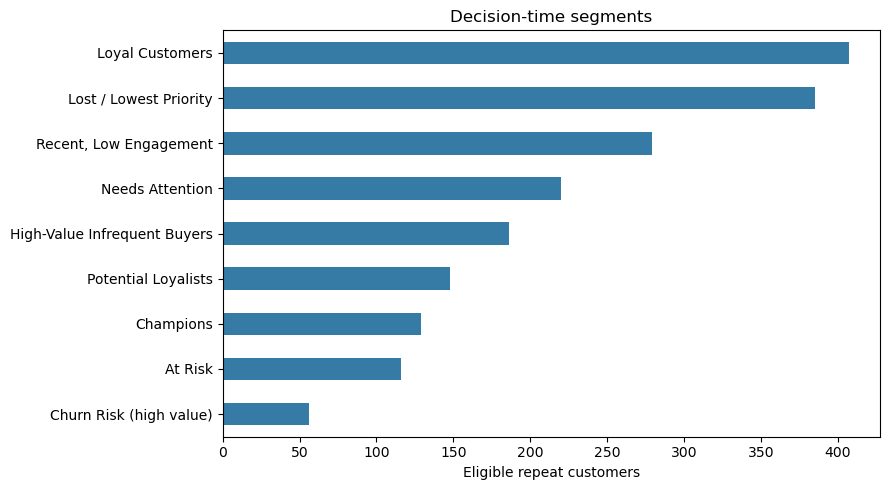

In [17]:
sizes = rfm["segment"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
sizes.plot.barh(ax=ax, color="#367ba5")
ax.set(title="Decision-time segments", xlabel="Eligible repeat customers", ylabel="")
fig.tight_layout(); plt.show(); plt.close(fig)

**Reading the segment counts.** Loyal Customers (407) and Lost / Lowest Priority
(385) are the two largest groups; Champions and Churn Risk (high value) are both narrow
by construction -- 56 customers in the latter. Segment widths aren't meant to be equal:
frequency ties (a lot of customers share exactly 2 or 3 orders) mean the quintile
boundaries don't cut the population into five even slices, and the rule chain above
routes different quintile combinations into buckets of very different natural size.

## 4. Cohorts as a descriptive lens

Also from Katherine Munro's "Methods for Modelling CLV": applying CLV/retention
analysis to segments defined by acquisition month, to see whether newer customers
behave differently from older ones. A cohort here is the calendar month of a
customer's **first observed calibration order** -- not verified acquisition. That distinction matters specifically for December
2010, the first month in the dataset: some of its "new" customers are really
pre-existing customers who simply hadn't been tracked before the extract's window
started. Cohort membership is never joined into the RFM features or the churn model --
it's kept as a separate, purely descriptive view.

In [18]:
order_dates = (cal.groupby(["CustomerID", "InvoiceNo"], as_index=False)["InvoiceDate"].min())
order_dates["month"] = order_dates["InvoiceDate"].dt.to_period("M")
order_dates["first_month"] = order_dates.groupby("CustomerID")["month"].transform("min")
order_dates["age"] = ((order_dates["month"].dt.year - order_dates["first_month"].dt.year) * 12
                      + order_dates["month"].dt.month - order_dates["first_month"].dt.month)

cohort_sizes = order_dates.groupby("first_month")["CustomerID"].nunique()
active = order_dates.groupby(["first_month", "age"])["CustomerID"].nunique().unstack()
retention = active.div(cohort_sizes, axis=0)

print("First-observed customer counts by calibration month:")
print(cohort_sizes.to_string())

First-observed customer counts by calibration month:
first_month
2010-12    884
2011-01    414
2011-02    381
2011-03    451
2011-04    300
2011-05    283
2011-06    242
2011-07    187
2011-08    169
Freq: M


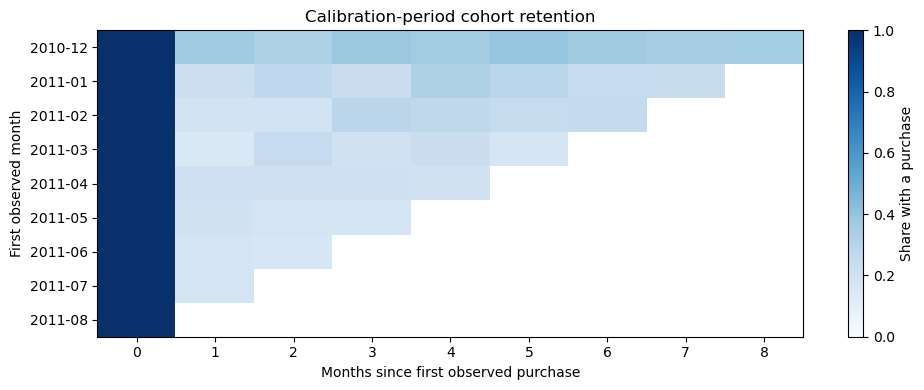

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
image = ax.imshow(retention.to_numpy(), aspect="auto", cmap="Blues", vmin=0, vmax=1)
ax.set(xticks=range(len(retention.columns)), xticklabels=retention.columns,
       yticks=range(len(retention.index)), yticklabels=retention.index.astype(str),
       xlabel="Months since first observed purchase", ylabel="First observed month",
       title="Calibration-period cohort retention")
fig.colorbar(image, ax=ax, label="Share with a purchase")
fig.tight_layout(); plt.show(); plt.close(fig)

**Reading the cohort heatmap.** Month zero is 100% by construction. Every cohort
falls off steeply by month one, consistent with a non-contractual retail business where
most customers buy once and don't return. December 2010 stands apart on two counts: it's
by far the largest cohort (**884** first-observed customers, against a few hundred for
every other month) and it retains noticeably higher early on.

Left-censoring is the simplest explanation, and it's a structural property of where the
dataset's window happens to start -- not something further cleaning could fix. A
customer who'd already been shopping with this retailer for a year before December 2010
still shows up as "first observed" the moment the extract's tracking window begins,
and naturally looks more loyal and higher-value than someone genuinely new, because part
of their apparent tenure and repeat-purchase pattern was always there -- it just wasn't
visible before the extract starts. Documented here as an acknowledged limitation of this
particular cohort, not solved further.

## 5. Inspect segment outcomes without leaking them into RFM

A last check before saving: how does actual churn vary across segments, on train and
validation only? This is read-only description -- nothing here feeds back into the RFM
scores or cutpoints above, and small segments (the audit below has one with single
digits on validation) make any one row's number noisy.

In [20]:
audit = (rfm[["CustomerID", "segment"]]
         .merge(manifest[["CustomerID", "split", "churned", "n_orders_holdout"]],
                on="CustomerID", validate="one_to_one"))
outcome_table = (audit.loc[audit["split"].isin(["train", "validation"])]
                 .groupby(["split", "segment"]).agg(
                     n=("CustomerID", "size"),
                     churn_rate=("churned", "mean"),
                     holdout_orders=("n_orders_holdout", "sum")).reset_index())
outcome_table

,split,segment,n,churn_rate,holdout_orders
0,train,At Risk,71,0.323944,101
1,train,Champions,74,0.013514,659
2,train,Churn Risk (high value),34,0.264706,63
3,train,High-Value Infrequent Buyers,116,0.387931,112
4,train,Lost / Lowest Priority,241,0.493776,195
5,train,Loyal Customers,242,0.132231,671
6,train,Needs Attention,133,0.406015,138
7,train,Potential Loyalists,89,0.123596,237
8,train,"Recent, Low Engagement",155,0.341935,180
9,validation,At Risk,29,0.344828,43


Segment outcome rates are descriptive only, and several segments are thin enough
(single digits in validation for Churn Risk (high value)) that any one row shouldn't be
over-read. Whether these outcome rates end up correlating suspiciously closely with the
segments themselves -- which is exactly what happened in the first iteration -- is a
question notebook 6 comes back to once the churn model and threshold are in place.

## 6. Save the shared manifest, RFM table, and frozen cutpoints

In [21]:
PROCESSED_DATA.mkdir(parents=True, exist_ok=True)
manifest.to_parquet(PROCESSED_DATA / "retail_population_manifest.parquet", index=False)
rfm.to_parquet(PROCESSED_DATA / "retail_rfm.parquet", index=False)

config = {
    "calibration_end": str(CALIBRATION_END.date()),
    "observation_end": str(OBSERVATION_END.date()),
    "eligible_population": "at_least_two_distinct_calibration_invoices",
    "split_seed": 42,
    "split": [0.6, 0.2, 0.2],
    "rfm_cutpoints": {k: v.tolist() for k, v in cutpoints.items()},
}
with (PROCESSED_DATA / "retail_config.json").open("w") as f:
    json.dump(config, f, indent=2)

print("Saved manifest, RFM table, and config")

Saved manifest, RFM table, and config


### Summary

- Defined **one canonical population**: 1,926 eligible repeat customers (>=2
  calibration invoices), split 60/20/20 (train/validation/test) and reused unchanged
  through notebook 6. 974 customers are first-seen-in-holdout and 1,385 have a single
  calibration order -- both excluded from the decision population rather than folded
  into a churn-risk bucket.
- **Historic CLV** is reported as observed calibration revenue -- median £539, mean
  £1,508, driven by a heavy right tail -- with an explicitly-flagged 25%-margin variant
  alongside it.
- **RFM is decision-time**: recency measured from the last calibration purchase (not
  the dataset's full history), and quintile cutpoints fit on train customers only, then
  frozen for validation and test. Both choices exist specifically to keep RFM from
  leaking the churn outcome it's meant to help predict.
- Nine segments, ranging from Champions (129) to Lost / Lowest Priority (385), with a
  correlation check confirming why "top-tier on all three" is more common than pure
  independence would suggest.
- Cohort retention shows the expected steep early drop-off, plus a left-censored
  December 2010 cohort -- documented, not solved, since it's a property of where the
  dataset's window starts.

**Next:** `03_Predictive_CLV.ipynb` -- benchmark a simple historic-rate extrapolation
against a train-fitted ML model, and test whether a BG-NBD/Gamma-Gamma probabilistic
approach is even numerically usable on this population.